# PROJECT 1 (1.1 1 img 1 model)

In [1]:
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.4 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# model

In [4]:
from ultralytics.utils import ASSETS

print(ASSETS)

/usr/local/lib/python3.12/dist-packages/ultralytics/assets


In [5]:
import os

print(os.listdir(ASSETS))

['zidane.jpg', 'bus.jpg']


In [6]:
image_path = os.path.join(ASSETS, "bus.jpg")
print(image_path)

/usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg


In [7]:
results = model.predict(
    source=image_path
)


image 1/1 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 1 bus, 8.4ms
Speed: 66.9ms preprocess, 8.4ms inference, 42.9ms postprocess per image at shape (1, 3, 640, 480)


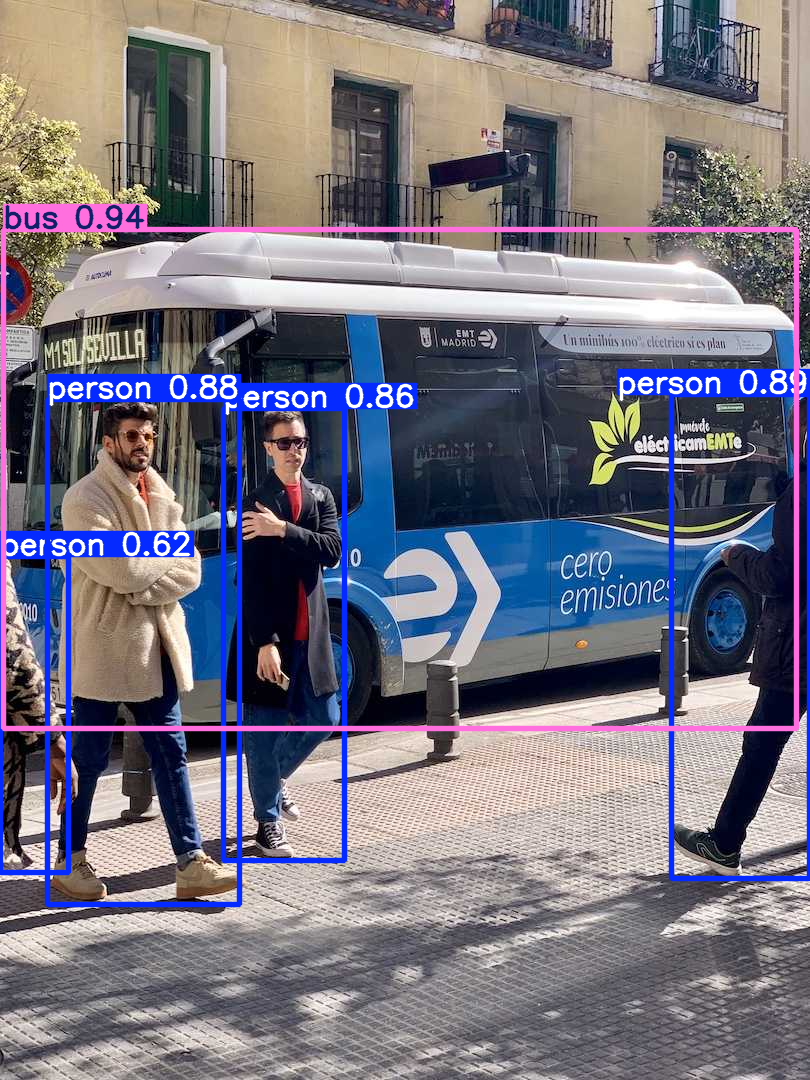

In [8]:
results[0].show()

In [9]:
# sebenarnya dah kelar sampe atas, tapi targetnya belajar jadi kita kulik 

result = results[0]
print(type(result))


<class 'ultralytics.engine.results.Results'>


In [10]:
print(result.boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.], device='cuda:0')
conf: tensor([0.9402, 0.8882, 0.8783, 0.8558, 0.6219], device='cuda:0')
data: tensor([[3.8328e+00, 2.2936e+02, 7.9619e+02, 7.2841e+02, 9.4015e-01, 5.0000e+00],
        [6.7102e+02, 3.9483e+02, 8.0981e+02, 8.7871e+02, 8.8822e-01, 0.0000e+00],
        [4.7405e+01, 3.9957e+02, 2.3930e+02, 9.0419e+02, 8.7825e-01, 0.0000e+00],
        [2.2306e+02, 4.0869e+02, 3.4447e+02, 8.6044e+02, 8.5577e-01, 0.0000e+00],
        [2.1726e-02, 5.5607e+02, 6.8886e+01, 8.7236e+02, 6.2192e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[400.0137, 478.8882, 792.3618, 499.0480],
        [740.4135, 636.7728, 138.7925, 483.8794],
        [143.3527, 651.8801, 191.8959, 504.6298],
        [283.7633, 634.5622, 121.4086, 451.7470],
        [ 34.4536, 714.2139,  68.8638, 316.2907]], device='cuda:0')
xywhn: tensor([[0.4938, 0.4434, 0.97

In [11]:
# bounding box
boxes = result.boxes
print(boxes.xyxy)

tensor([[3.8328e+00, 2.2936e+02, 7.9619e+02, 7.2841e+02],
        [6.7102e+02, 3.9483e+02, 8.0981e+02, 8.7871e+02],
        [4.7405e+01, 3.9957e+02, 2.3930e+02, 9.0419e+02],
        [2.2306e+02, 4.0869e+02, 3.4447e+02, 8.6044e+02],
        [2.1726e-02, 5.5607e+02, 6.8886e+01, 8.7236e+02]], device='cuda:0')


In [12]:
# confident
print(boxes.conf)

tensor([0.9402, 0.8882, 0.8783, 0.8558, 0.6219], device='cuda:0')


In [13]:
# class id
print(boxes.cls)

tensor([5., 0., 0., 0., 0.], device='cuda:0')


In [14]:
for i in range(len(boxes)):
    class_id = int(boxes.cls[i])
    confidence = float(boxes.conf[i])
    bbox = boxes.xyxy[i].tolist()

    class_name = result.names[class_id]

    print(
        class_name,
        confidence,
        bbox
    )

bus 0.9401525259017944 [3.8327693939208984, 229.36419677734375, 796.194580078125, 728.4122314453125]
person 0.8882198929786682 [671.0172119140625, 394.83306884765625, 809.8097534179688, 878.7124633789062]
person 0.8782548308372498 [47.404727935791016, 399.5651550292969, 239.3006591796875, 904.1949462890625]
person 0.8557726740837097 [223.05899047851562, 408.6886901855469, 344.4676208496094, 860.4357299804688]
person 0.6219195127487183 [0.021725893020629883, 556.0685424804688, 68.88553619384766, 872.3592529296875]


# PROJECT 1 (1.2 banyak img 1 model)

In [15]:
# kode diatas ttp kepake kita lanjutin saja
import os 
print(os.listdir(ASSETS))

['zidane.jpg', 'bus.jpg']


In [16]:
img_paths = [
    os.path.join(ASSETS, "zidane.jpg"),
    os.path.join(ASSETS, "bus.jpg")
]
print(img_paths)

['/usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg', '/usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg']


In [17]:
hasil = model.predict(
    source=img_paths,
    conf=0.5 # kasi treshold
)


0: 640x640 2 persons, 33.1ms
1: 640x640 3 persons, 1 bus, 33.1ms
Speed: 2.1ms preprocess, 33.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


In [18]:
print(len(results))

1


image: 0


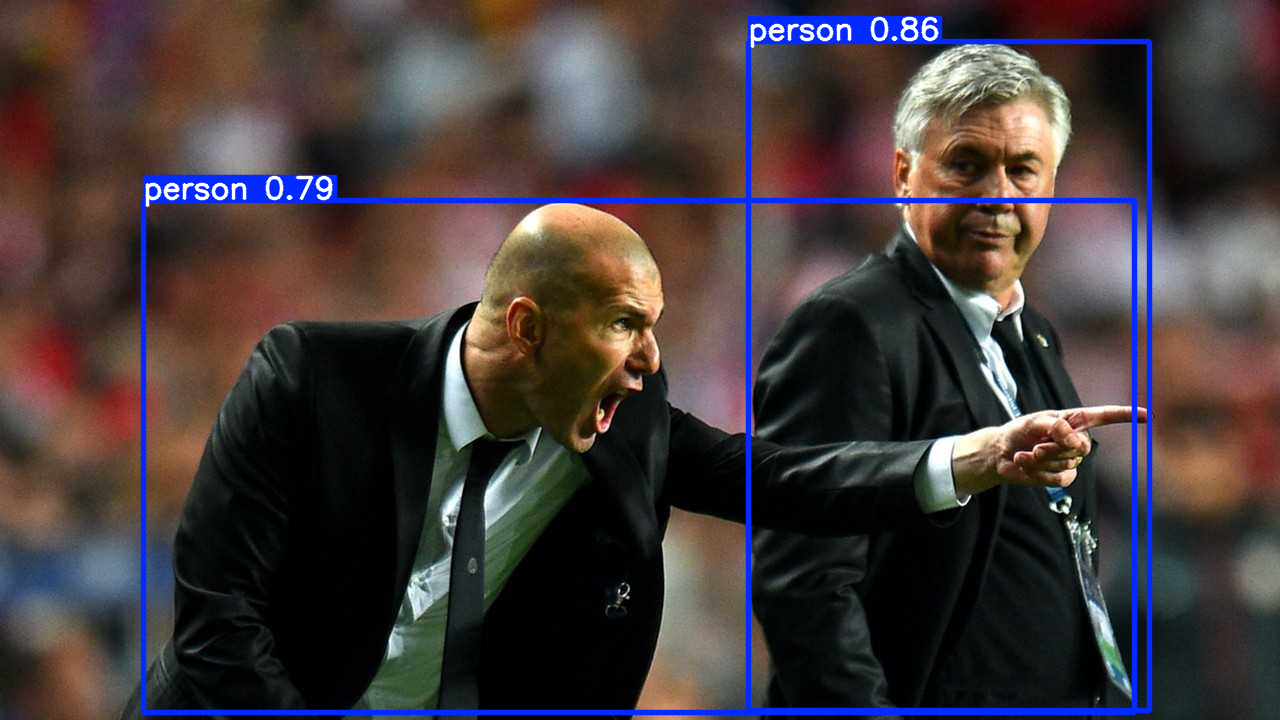

image: 1


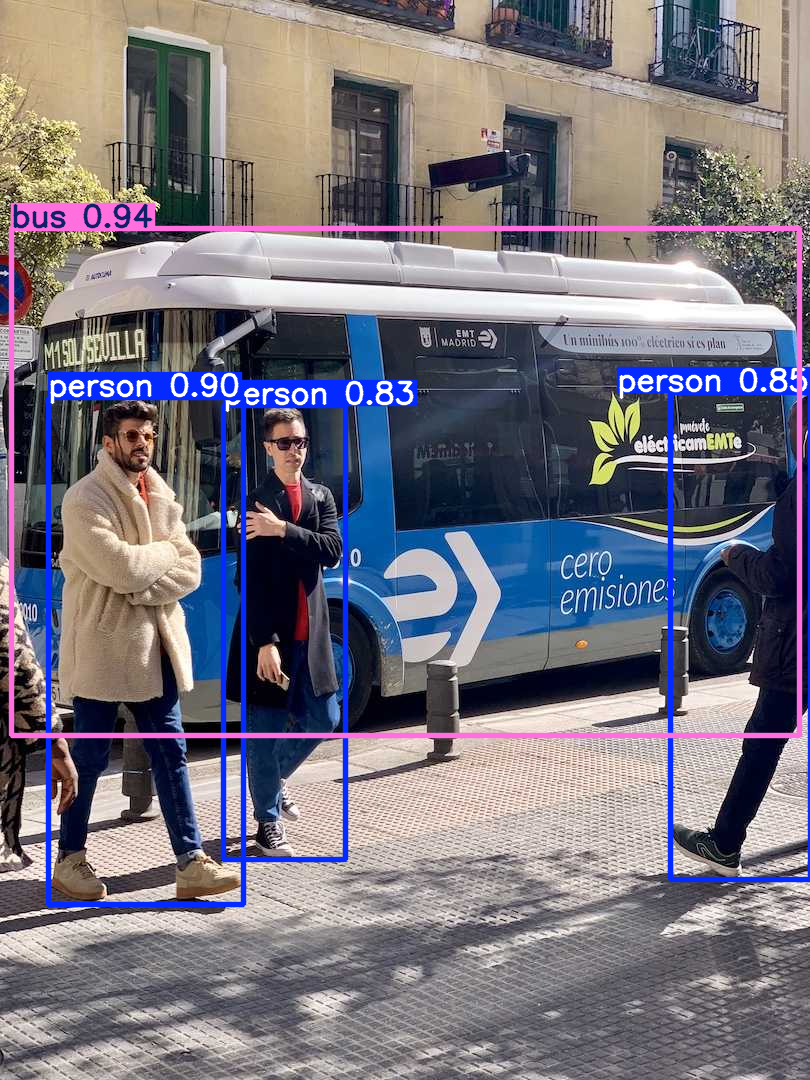

In [19]:
for i, result in enumerate(hasil):
    print(f'image: {i}')
    result.show()

In [20]:
for i, result in enumerate(hasil):
    boxes = result.boxes
    print(f"\nImage {i}")
    print("Jumlah object:", len(boxes))


Image 0
Jumlah object: 2

Image 1
Jumlah object: 4


In [21]:
# kelas
for i, result in enumerate(hasil):
    boxes = result.boxes
    print(f"\nImage {i}")
    print(f"conf model: ", len(boxes.conf))
    print(f"class : ", len(boxes.cls))


Image 0
conf model:  2
class :  2

Image 1
conf model:  4
class :  4


In [22]:
for i, result in enumerate(hasil):

    print(f"\n===== IMAGE {i} =====")

    boxes = result.boxes

    for j in range(len(boxes)):

        class_id = int(boxes.cls[j])
        confidence = float(boxes.conf[j])
        bbox = boxes.xyxy[j].tolist()

        class_name = result.names[class_id]

        print(
            f"Class: {class_name} | "
            f"Confidence: {confidence:.2f} | "
            f"Box: {bbox}"
        )


===== IMAGE 0 =====
Class: person | Confidence: 0.86 | Box: [748.78955078125, 41.369232177734375, 1149.3870849609375, 710.7779541015625]
Class: person | Confidence: 0.79 | Box: [143.0814208984375, 200.774658203125, 1134.8446044921875, 712.4093017578125]

===== IMAGE 1 =====
Class: bus | Confidence: 0.94 | Box: [11.91848373413086, 228.39422607421875, 799.2252197265625, 735.2149047851562]
Class: person | Confidence: 0.90 | Box: [48.59273147583008, 397.960693359375, 243.21273803710938, 904.5357666015625]
Class: person | Confidence: 0.85 | Box: [670.556396484375, 392.5901184082031, 810.0, 879.6234130859375]
Class: person | Confidence: 0.83 | Box: [223.11959838867188, 405.5780029296875, 345.2289733886719, 859.7220458984375]


In [23]:
for i, result in enumerate(hasil):

    person_count = 0

    boxes = result.boxes

    for j in range(len(boxes)):

        class_id = int(boxes.cls[j])
        confidence = float(boxes.conf[j])

        if class_id == 0:
            person_count += 1

    print(f"Image {i}: {person_count} person")

Image 0: 2 person
Image 1: 3 person
